# Docs Examples

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
from diffinytrace.basis_functions.bspline import basis_2D
import torch


In [2]:
cube = dit.integrators.Cube([[0, 1], [0, 1]])
points, weights = cube.sample([10, 10], method="midpoint")
volume = cube.get_volume()
all_in_bounds = cube.in_bounds(points)

print("Sampled points:\n", points)
print("Integration weights:\n", weights)
print("Cube volume:", volume)
print("All points in bounds:", all_in_bounds)

Sampled points:
 tensor([[0.0500, 0.0500],
        [0.0500, 0.1500],
        [0.0500, 0.2500],
        [0.0500, 0.3500],
        [0.0500, 0.4500],
        [0.0500, 0.5500],
        [0.0500, 0.6500],
        [0.0500, 0.7500],
        [0.0500, 0.8500],
        [0.0500, 0.9500],
        [0.1500, 0.0500],
        [0.1500, 0.1500],
        [0.1500, 0.2500],
        [0.1500, 0.3500],
        [0.1500, 0.4500],
        [0.1500, 0.5500],
        [0.1500, 0.6500],
        [0.1500, 0.7500],
        [0.1500, 0.8500],
        [0.1500, 0.9500],
        [0.2500, 0.0500],
        [0.2500, 0.1500],
        [0.2500, 0.2500],
        [0.2500, 0.3500],
        [0.2500, 0.4500],
        [0.2500, 0.5500],
        [0.2500, 0.6500],
        [0.2500, 0.7500],
        [0.2500, 0.8500],
        [0.2500, 0.9500],
        [0.3500, 0.0500],
        [0.3500, 0.1500],
        [0.3500, 0.2500],
        [0.3500, 0.3500],
        [0.3500, 0.4500],
        [0.3500, 0.5500],
        [0.3500, 0.6500],
        [0.3500, 0.75

In [3]:
from diffinytrace.integrators import IntegrationMethod
disc = dit.integrators.Disc(1.0)
points, weights = disc.sample(2**4, method=IntegrationMethod.SOBOL)
volume = disc.get_volume()
all_in_bounds = disc.in_bounds(points)
print("Sampled points:", points)
print("Integration weights:", weights)
print("Disc area:", volume)
print("All points in bounds:", all_in_bounds)


Sampled points: tensor([[-0.4342,  0.6944],
        [ 0.2433, -0.2747],
        [ 0.5467,  0.3128],
        [-0.7059, -0.6519],
        [ 0.1017,  0.9053],
        [-0.2282, -0.5603],
        [-0.3153,  0.0579],
        [ 0.7257, -0.2234],
        [ 0.7343,  0.0757],
        [-0.0875, -0.0347],
        [-0.0989,  0.5121],
        [ 0.2708, -0.8515],
        [-0.8329,  0.5103],
        [ 0.5284, -0.4595],
        [ 0.2410,  0.4123],
        [-0.5740, -0.6102]])
Integration weights: tensor([0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963,
        0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963])
Disc area: 3.141592653589793
All points in bounds: tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])


In [4]:
callback_fun = lambda:None
callback_fun()

In [5]:
import diffinytrace.config as config
config.set_tolerance(1e-8)
config.set_show_iteration_count(True)
config.restore_default_settings()

tensor(0.) tensor(1.)


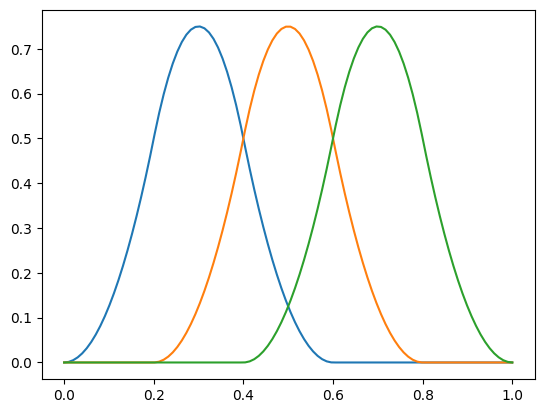

In [6]:

import torch
import matplotlib.pyplot as plt
from diffinytrace.basis_functions import bspline
U = torch.tensor([0., 0.2, 0.4, 0.6, 0.8, 1])
n = 3
k = 3  # This is order 3
print(U[0], U[-1])
xis = torch.linspace(0, 1, 100)
xN = bspline.basis_1D(xis, U,k ,n,[0.,1.])
num_points = xN.shape[0]
tmp = xN.reshape(num_points, -1, 1) * xN.reshape(num_points, 1, -1)
for yin in xN.T:
    plt.plot(xis, yin)
plt.gca().set_aspect('equal')


True True
new_control_points tensor([[ 0.2965,  0.4003],
        [ 0.6730,  0.7288],
        [ 0.1156,  0.4104],
        [ 0.3161, -0.3015],
        [ 0.6194, -0.5390]])
control_points tensor([[ 0.2965,  0.4003],
        [ 0.8671,  0.8982],
        [-0.2720,  0.1589],
        [ 0.6194, -0.5390]])
new_control_points tensor([[ 0.2965,  0.4003],
        [ 0.7163,  0.7666],
        [ 0.0290,  0.3542],
        [ 0.3839, -0.3546],
        [ 0.6194, -0.5390]])
control_points tensor([[ 0.2965,  0.4003],
        [ 0.8671,  0.8982],
        [-0.2720,  0.1589],
        [ 0.6194, -0.5390]])
new_control_points tensor([[ 0.2965,  0.4003],
        [ 0.3291,  0.4288],
        [ 0.8019,  0.8559],
        [-0.2210,  0.1189],
        [ 0.6194, -0.5390]])
control_points tensor([[ 0.2965,  0.4003],
        [ 0.8671,  0.8982],
        [-0.2720,  0.1589],
        [ 0.6194, -0.5390]])
new_control_points tensor([[ 0.2965,  0.4003],
        [ 0.4163,  0.5048],
        [ 0.6280,  0.7430],
        [-0.0849,  0.01

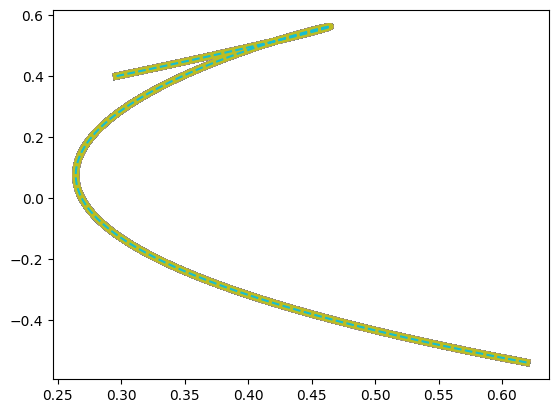

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
n = 4
control_points = torch.randn((n, 2))  # Random control points
k = 4  # Quadratic B-spline
U = torch.tensor([0.0] * (k - 1) + list(np.linspace(0, 1.0, n + k - 2 * (k - 1))) + [1.0] * (k - 1))
U = U.float()
print(U.shape[0] - k == n, n >= k)
for m in range(100):
    U_new, new_control_points = bspline.insert_knot_1D_single(U, k, torch.rand((1)), control_points)
    print("new_control_points", new_control_points)
    print("control_points", control_points)
    xis = torch.linspace(0, 1, 1000)
    xN1 = bspline.basis_1D(xis,U, k, 3, [0,1.])
    out1 = xN1 @ control_points
    xN2 = bspline.basis_1D(xis,U_new, k, 4, [0,1.])
    out2 = xN2 @ new_control_points
    plt.plot(out1[:, 0], out1[:, 1], linewidth=5.0)
    plt.plot(out2[:, 0], out2[:, 1], "--")
    torch.mean((out1 - out2) ** 2)

In [8]:
import torch
from diffinytrace.basis_functions import bspline
n_x, n_y = 4, 4
control_points = torch.randn((n_x, n_y, 2))
k_x, k_y = 3, 3
U_x = torch.linspace(0, 1, n_x + k_x)
U_y = torch.linspace(0, 1, n_y + k_y)
points = torch.rand((100, 2))
surface = bspline.surface_2D(points, [U_x, U_y], [k_x, k_y], [n_x, n_y], (0.0, 1.0), (0.0, 1.0), control_points)
surface

tensor([[ 1.7537e-02,  1.6464e-02],
        [-8.3224e-01,  1.3358e+00],
        [ 7.8279e-01,  1.0403e+00],
        [-2.1668e-01, -7.0224e-02],
        [-2.3779e-01, -1.0671e-01],
        [-7.4834e-04,  6.4871e-02],
        [ 1.7008e-01,  9.8757e-01],
        [ 4.8270e-01,  5.7388e-01],
        [-8.4862e-01,  1.2127e+00],
        [ 1.9593e-02,  3.0075e-02],
        [ 4.9341e-01,  7.1013e-01],
        [ 1.0490e-02,  6.3028e-01],
        [-4.6881e-01, -1.4220e-01],
        [-1.9502e-03, -5.8600e-04],
        [ 9.7925e-01,  3.0117e-03],
        [ 5.0811e-03,  8.9721e-03],
        [ 4.9538e-03,  8.2468e-02],
        [ 4.9913e-03,  7.6619e-03],
        [-1.1655e-01,  1.8080e-01],
        [ 5.2846e-01,  1.1284e+00],
        [ 3.4732e-03,  6.4989e-03],
        [ 3.6518e-01,  3.9506e-01],
        [ 5.7310e-01,  1.1133e+00],
        [-8.8996e-01,  1.3605e+00],
        [ 6.7045e-02,  5.1943e-01],
        [ 2.9589e-03,  8.2451e-02],
        [ 4.7437e-01,  7.1159e-01],
        [ 2.6678e-01,  8.633

In [9]:
import torch
import diffinytrace as dit

aperture_half = 30.0
aperture_radius = aperture_half
lens_thickness = 8.0
material = dit.materials["NBK7"]
transform = dit.transforms.Identity()

# degree [p, q] and control net size [n_u, n_v] (example values)
bspline = dit.Bspline(aperture_half, [3, 3], [8, 8])
plane = dit.Plane()

with torch.no_grad():
    bspline.coeff.data = torch.randn_like(bspline.coeff.data) * 3.0

lens = dit.Lens(transform, lens_thickness, bspline, plane,
                       material, aperture_radius)

dit.plotting.system3D.plot(lens, zticks=[0, 5])

c:\Users\marti\anaconda3\envs\dit\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


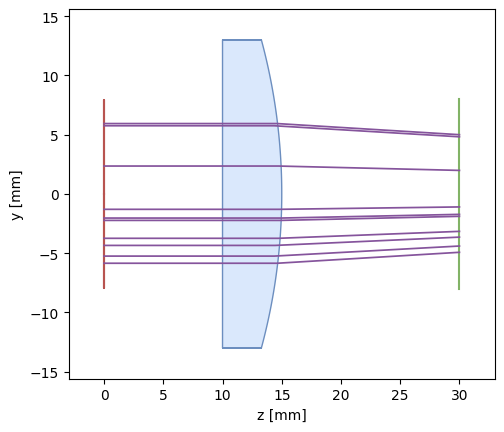

In [10]:
import diffinytrace as dit
import torch
NBK7 = dit.materials["NBK7"]

wave_len = 1.024
light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
source = dit.source.CollimatedMonochromatic(light_transform,8.0,wave_len)

plane_surface = dit.Plane()
surface2 = dit.Aspheric(-1/50.)
transf1 = dit.transforms.Distance(10.0,parent_transform=source)
lens1 = dit.Lens(transf1,5.,plane_surface,surface2,NBK7,13.0)
transf2 = dit.transforms.Distance(15.0,parent_transform=lens1)
detector = dit.Detector(transf2,plane_surface,8.0)
system = dit.SequentialOpticalSystem({"source":source, "lens":lens1, "detector":detector})
#dit.plotting.system3D.plot(system,resolution=10)
x,weights = source.sample(10)
O,D,wave_len,_,meta_data = system(x,["source","lens","detector"])
dit.plotting.system2D.plot(system,meta_data)

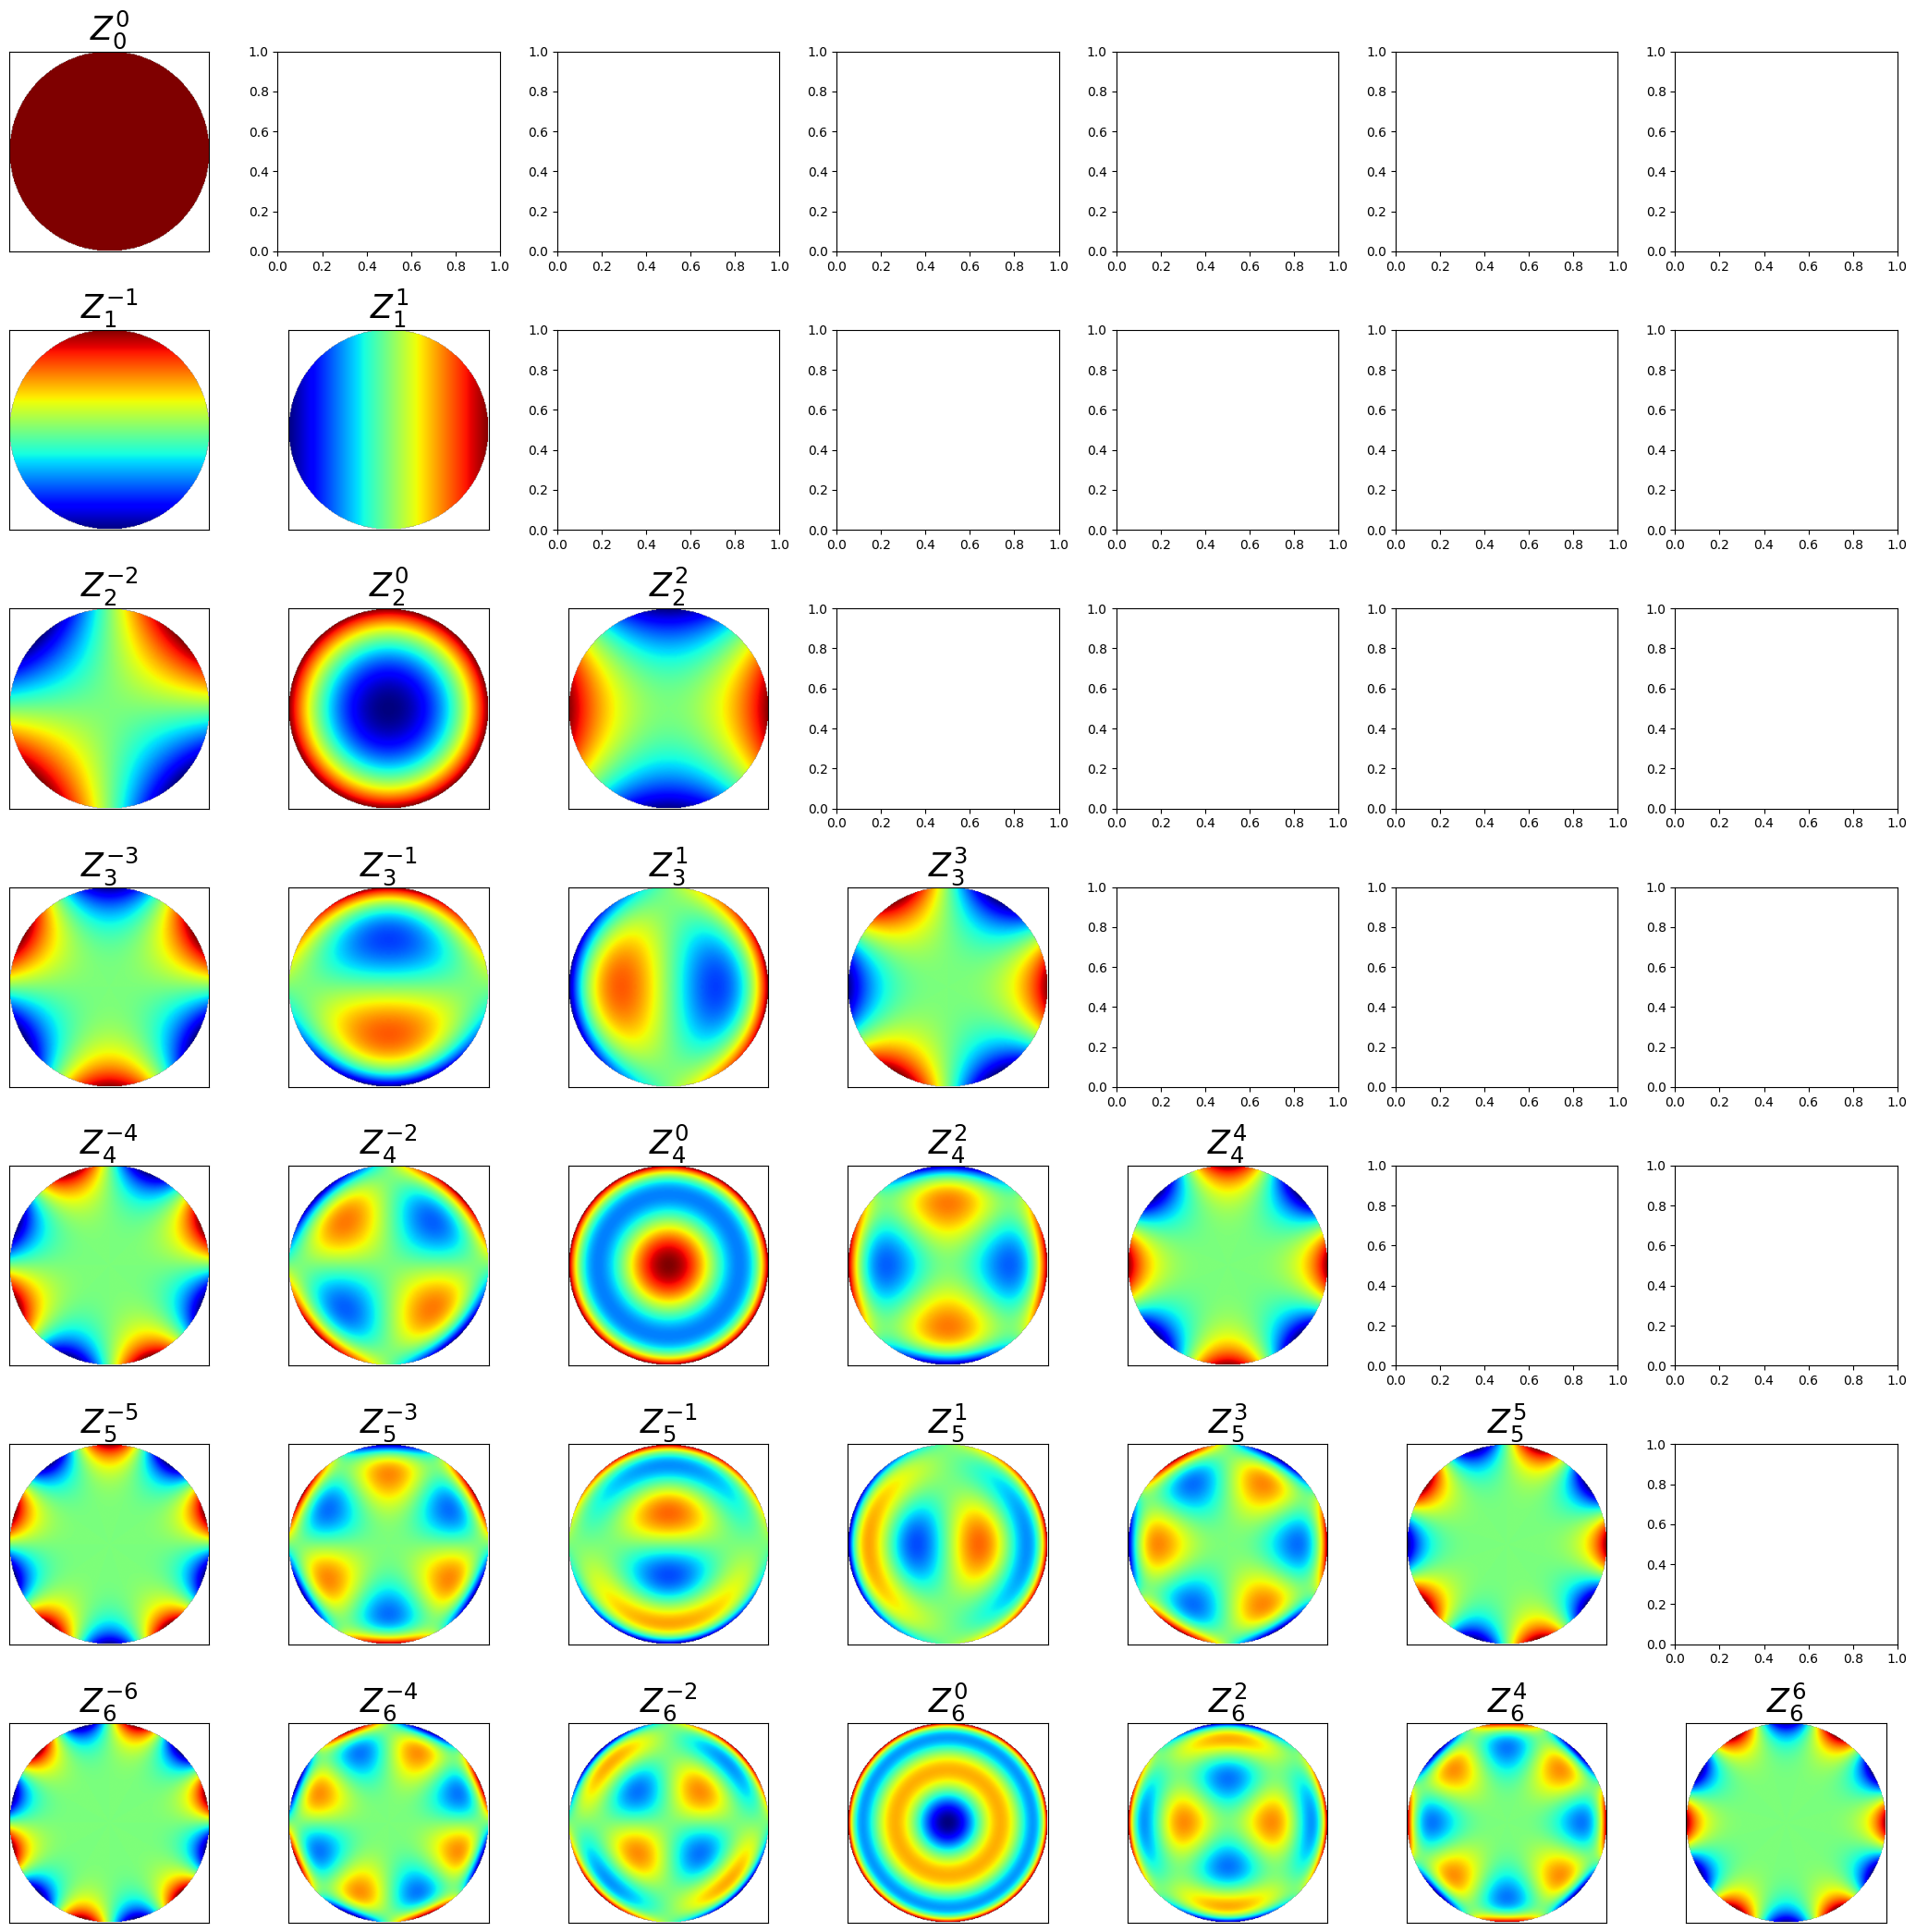

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import diffinytrace.basis_functions.zernike as zernike

# Create unit circle grid
grid_size = 256
x = torch.linspace(-1, 1, grid_size)
y = torch.linspace(-1, 1, grid_size)
X, Y = torch.meshgrid(x, y, indexing='ij')

# Create mask for unit circle
mask = (X**2 + Y**2) <= 1.0
x_points = X[mask]
y_points = Y[mask]
points = torch.stack([x_points, y_points], dim=1)

# Evaluate Zernike polynomials
max_n = 6  # Maximum radial degree
basis_values = zernike.basis_2D(points,max_n)

# Group basis functions by radial degree
basis_by_degree = {}
for basis_idx in range(basis_values.shape[1]):
    radial_order = zernike.get_radial_order(basis_idx)
    if radial_order not in basis_by_degree:
        basis_by_degree[radial_order] = []
    basis_by_degree[radial_order].append(basis_idx)

# Visualize the polynomials
max_cols = max(len(indices) for indices in basis_by_degree.values())
num_rows = len(basis_by_degree)
fig, axes = plt.subplots(num_rows, max_cols, figsize=(3*max_cols, 3*num_rows))
    
for row_idx, (radial_order, basis_indices) in enumerate(sorted(basis_by_degree.items())):
    for col_idx, basis_idx in enumerate(basis_indices):
        tmp = torch.full((grid_size, grid_size), float('nan'))
        tmp[mask] = basis_values[:, basis_idx]
        ax = axes[row_idx, col_idx]
        im = ax.imshow(tmp.numpy(), extent=[-1, 1, -1, 1],
                        origin='lower', cmap='jet', vmin=-1, vmax=1)
        azimuthal = zernike.get_azimuthal_frequency(basis_idx)
        ax.set_title(f"$Z^{{{azimuthal}}}_{{{radial_order}}}$", fontsize=25)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [12]:
x = torch.tensor([0.])
y = torch.tensor([0.])
torch.atan2(y, x)

tensor([0.])